<h1 style="color:orange">Data Cleaning and Preprocessing</h1>

<a href="https://app.notion.com/p/builderslab/Perform-Data-Cleaning-and-Preprocessing-371663a5d5d180648531ce25fee5909b">
  <img src="https://cdn.simpleicons.org/notion/000000" width="16" style="vertical-align:middle; margin-right:4px"/> Notion Task
</a>
&nbsp;|&nbsp;
<a href="https://github.com/BuildersLab/Credit-Risk-Default">
  <img src="https://cdn.simpleicons.org/github/181717" width="16" style="vertical-align:middle; margin-right:4px"/> GitHub Repo
</a>

## Table of Contents

1. [Import Libraries and Load Dataset](#import-libraries-and-load-dataset)
2. [Data Cleaning](#data-cleaning)
   - [1. Data Inspection](#1-data-inspection)
   - [2. Duplicate Values](#3-duplicate-values)
   - [3. Missing Values](#4-missing-values)
     - [3.1 Missing Values Summary](#41-missing-values-summary)
     - [3.2 Missing Values Handling](#42-missing-values-handling)
   - [4. Leakage Columns](#5-leakage-columns)
   - [5. Outliers](#6-outliers)

### Documentation

**Dataset Source:** [Kaggle: All Lending Clud Dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club/data)

---

**Target Variable:** Binary outcome based on known loan resolution

| Label | Value | Loan Status |
|---|---|---|
| Not Default | 0 | Fully Paid |
| Default | 1 | Charged Off, Default, Late (31–120 days) |

Rows excluded from target variable:
- `Current` (878,317) - loan still active, outcome unknown
- `In Grace Period` (8,436) - outcome uncertain
- `Late (16-30 days)` (4,349) - outcome uncertain

---

**Cleaning Steps:**

| Step | Description |
|---|---|
| 1. Data Inspection | Shape, sample, columns, summary statistics |
| 2. Data Types | Check and correct data types |
| 3. Duplicate Values | Check and remove duplicate rows |
| 4. Missing Values | Identify, analyse, and handle missing data |
| 5. Leakage Columns | Remove post-origination features that leak the target |
| 6. Outliers | Flag and handle extreme values |

<h2 style="color:orange"><a id="import-libraries-and-load-dataset"></a>I. Import Libraries and Load Dataset</h2>

In [1]:
# Import libraries
import os
import time
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Define directory path
BASE_DIR = os.path.dirname(os.path.abspath(os.getcwd()))

# Define path to output folder
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

# Print the base directory
print(f"Base directory: {BASE_DIR}")

Base directory: c:\Users\Nafis\BuildersLab_projects\Teams\Credit-Risk-Default


In [3]:
# Display all columns in the output 
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)


In [4]:
# Import kagglehub
"""import sys
print(sys.executable)
!{sys.executable} -m pip install kagglehub"""

'import sys\nprint(sys.executable)\n!{sys.executable} -m pip install kagglehub'

In [5]:
# Import the dataset from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

# Check the path where the dataset files are stored
print("Path to dataset files:", path)

# Check the files that are available in the dataset
print(os.listdir(path))

Path to dataset files: C:\Users\Nafis\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3
['accepted_2007_to_2018q4.csv', 'accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv.gz']


Note: Kaggle returns 4 different files:
- accepted_2007_to_2018q4.csv
- accepted_2007_to_2018Q4.csv.gz
- rejected_2007_to_2018q4.csv
- rejected_2007_to_2018Q4.csv.gz

The .gz is the compressed version, and the .csv is the same data uncompressed. We're only considering "accepted" data becasue it contains all features/variables needed for the analysis and modeling.

In [6]:
# Start timer to measure the time taken to load the dataset
start_time = time.time()

# Load dataset
df = pd.read_csv(os.path.join(path, "accepted_2007_to_2018Q4.csv.gz"), low_memory=False)

# End timer and print the time taken to load the dataset
end_time = time.time()
print(f"Time taken to load the dataset: {end_time - start_time:.2f} seconds")

Time taken to load the dataset: 83.31 seconds


<h2 style="color:orange"><a id="data-cleaning"></a>II. Data Quality</h2>

- [1. Data Inspection](#1-data-inspection)
- [2. Duplicate Values](#3-duplicate-values)
- [3. Missing Values](#4-missing-values)
  - [3.1 Missing Values Summary](#41-missing-values-summary)
  - [3.2 Missing Values Handling](#42-missing-values-handling)
- [4. Leakage Columns](#5-leakage-columns)
- [5. Outliers](#6-outliers)

<h3 style="color:orange"><a id="1-data-inspection"></a>1. Data Inspection</h3>

In [7]:
# Check the shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (2260701, 151)


Note: The dataset has 2,260,701 rows and 151 columns.

In [8]:
# Check a sample of the dataset
print("Sample of the dataset:")
df.sample(5)

Sample of the dataset:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2018205,85331545,NaN,20000.0,20000.0,20000.0,60 months,13.99,465.27,C,C3,utility maintenance,7 years,MORTGAGE,48000.0,Verified,Jul-2016,Current,n,https://lendingclub.com/browse/loanDetail.action?loan_id=85331545,NaN,credit_card,Credit card refinancing,378xx,TN,31.33,0.0,Jan-1987,705.0,709.0,0.0,NaN,NaN,4.0,0.0,32927.0,97.1,16.0,w,11062.74,11062.74,14950.940000,14950.94,8937.26,5990.42,23.26,0.00,0.0000,Mar-2019,465.27,Apr-2019,Mar-2019,714.0,710.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,56783.0,0.0,1.0,1.0,2.0,8.0,23856.0,95.0,0.0,0.0,16313.0,96.0,33900.0,1.0,5.0,1.0,2.0,14196.0,973.0,97.1,0.0,0.0,133.0,354.0,80.0,8.0,1.0,141.0,NaN,8.0,NaN,0.0,3.0,3.0,3.0,6.0,7.0,3.0,8.0,3.0,4.0,0.0,0.0,0.0,1.0,100.0,100.0,0.0,0.0,58900.0,56783.0,33900.0,25000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
67011,64812948,NaN,12000.0,12000.0,12000.0,60 months,13.18,274.15,C,C3,Billing Analyst,5 years,OWN,45260.0,Source Verified,Nov-2015,Current,n,https://lendingclub.com/browse/loanDetail.action?loan_id=64812948,NaN,debt_consolidation,Debt consolidation,481xx,MI,19.97,0.0,Oct-1994,680.0,684.0,1.0,48.0,NaN,12.0,0.0,10272.0,59.7,40.0,w,4862.69,4862.69,11004.300000,11004.30,7137.31,3866.99,0.00,0.00,0.0000,Mar-2019,274.15,Apr-2019,Mar-2019,744.0,740.0,0.0,48.0,1.0,Individual,NaN,NaN,NaN,0.0,50.0,39112.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17200.0,NaN,NaN,NaN,4.0,3556.0,3000.0,75.2,0.0,0.0,138.0,253.0,3.0,3.0,0.0,7.0,48.0,3.0,48.0,2.0,4.0,6.0,5.0,19.0,6.0,10.0,33.0,6.0

In [9]:
# Display all columns
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_j

In [10]:
# Check info
print("Info about the dataset:")
df.info(verbose=True, show_counts=True) # Display all columns and count of non-null values

Info about the dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 151 columns):
 #    Column                                      Non-Null Count    Dtype  
---   ------                                      --------------    -----  
 0    id                                          2260701 non-null  str    
 1    member_id                                   0 non-null        float64
 2    loan_amnt                                   2260668 non-null  float64
 3    funded_amnt                                 2260668 non-null  float64
 4    funded_amnt_inv                             2260668 non-null  float64
 5    term                                        2260668 non-null  str    
 6    int_rate                                    2260668 non-null  float64
 7    installment                                 2260668 non-null  float64
 8    grade                                       2260668 non-null  str    
 9    sub_grade                      

In [11]:
# Display summary statistics for numeric columns
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,2.260668e+06,2.260638e+06,1.102166e+06,359156.000000,2.260639e+06,2.260639e+06,2.260668e+06,2.258866e+06,2.260639e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260523e+06,580775.000000,2260668.0,1.207100e+05,120706.000000,2.260639e+06,2.190392e+06,2.190392e+06,1.394538e+06,1.394539e+06,1.394539e+06,1.394539e+06,1.350744e+06,1.394539e+06,1.191818e+06,1.394539e+06,1.394539e+06,1.394539e+06,1.394320e+06,2.190392e+06,1.394539e+06,1.394538e+06,1.394538e+06,2.210638e+06,2.190322e+06,2.185733e+06,2.184597e+06,2.260523e+06,2.260639e+06,2.121597e+06,2.190391e+06,2.190391e+06,2.190392e+06,2.210638e+06,2.187256e+06,519701.000000,1.965233e+06,740359.000000,2.190392e+06,2.190392e+06,2.190392e+06,2.202078e+06,2.190392e+06,2.190392e+06,2.190392e+06,2.190391e+06,2.190392e+06,2.202078e+06,2.107011e+06,2.190392e+06,2.190392e+06,2.190392e+06,2.190237e+06,2.185289e+06,2.259303e+06,2.260563e+06,2.190392e+06,2.210638e+06,2.210638e+06,2.190392e+06,1.080200e+05,108021.000000,108021.000000,108021.000000,108021.000000,108021.000000,106184.000000,108021.000000,108021.000000,108021.000000,108021.000000,35942.000000,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,7.025884e+02,5.768354e-01,3.454092e+01,72.312842,1.161240e+01,1.975278e-01,1.665846e+04,5.033770e+01,2.416255e+01,4.206891e+03,4.205965e+03,1.208256e+04,1.206439e+04,9.505772e+03,2.431388e+03,1.518453e+00,1.438791e+02,2.398257e+01,3.429346e+03,6.876610e+02,6.755397e+02,1.814580e-02,44.164220,1.0,1.236246e+05,19.251817,4.147942e-03,2.327317e+02,1.424922e+05,9.344199e-01,2.779407e+00,6.764314e-01,1.562752e+00,2.122236e+01,3.550665e+04,6.914098e+01,1.290133e+00,2.749923e+00,5.806393e+03,5.703230e+01,3.457394e+04,1.012867e+00,1.47

In [12]:
# Print all the values of the 'loan_status' column
print("Unique values in 'loan_status' column:")
print(df['loan_status'].unique().tolist())

Unique values in 'loan_status' column:
['Fully Paid', 'Current', 'Charged Off', 'In Grace Period', 'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan, 'Does not meet the credit policy. Status:Fully Paid', 'Does not meet the credit policy. Status:Charged Off']


In [13]:
# Count of values in 'loan_status' column
print("Count of values in 'loan_status' column:")
print(df['loan_status'].value_counts())


Count of values in 'loan_status' column:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


<h3 style="color:orange"><a id="3-duplicate-values"></a>3. Duplicate Values</h3>

In [14]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

# Check for duplicate values in the "id" column
print("Number of duplicate values in 'id' column:", df['id'].duplicated().sum())

Number of duplicate rows: 0
Number of duplicate values in 'id' column: 0


Note: The dataset has no duplicates.

<h3 style="color:orange"><a id="4-missing-values"></a>4. Missing Values</h3>

<h4 style="color:orange"><a id="41-missing-values-summary"></a>4.1 Missing Values Summary</h4>

In [15]:
# Summary of missing values
missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100

# Create a DataFrame to display the summary of missing values
missing_values_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_values_percentage
}).sort_values(by='Missing Values', ascending=False)

# Add 'column_name' as a column in the DataFrame
missing_values_summary['Column names'] = missing_values_summary.index

# Save to a csv file to outputs folder
missing_values_summary.to_csv(os.path.join(OUTPUT_DIR, "missing_values_summary.csv"))

print("Summary of missing values:")
missing_values_summary

Summary of missing values:


,Missing Values,Percentage (%),Column names
member_id,2260701,100.000000,member_id
orig_projected_additional_accrued_interest,2252050,99.617331,orig_projected_additional_accrued_interest
hardship_reason,2249784,99.517097,hardship_reason
hardship_payoff_balance_amount,2249784,99.517097,hardship_payoff_balance_amount
hardship_last_payment_amount,2249784,99.517097,hardship_last_payment_amount
payment_plan_start_date,2249784,99.517097,payment_plan_start_date
hardship_type,2249784,99.517097,hardship_type
hardship_status,2249784,99.517097,hardship_status
hardship_start_date,2249784,99.517097,hardship_start_date
deferral_term,2249784,99.517097,deferral_term


In [16]:
# Merge data_dictionary with missing values summary

# Load the data dictionary
data_dictionary = pd.read_csv(os.path.join(BASE_DIR, "data/processed/dictionary_accepted.csv"))

# Merge the data dictionary with the missing values summary
data_dictionary_summary = pd.merge(data_dictionary, missing_values_summary, left_on='Variable', right_on='Column names', how='left')

# Drop the redundant column
data_dictionary_summary = data_dictionary_summary.drop(columns=['Column names'])

# Create a new column for different missingness labels: "Empty (100%)", "Very High (95-99%)", "High (50-94%)", "Moderate (10-49%)", "Low (<10%)"
data_dictionary_summary['Missingness Label'] = pd.cut(
    data_dictionary_summary['Percentage (%)'],
    bins=[-1, 0, 10, 50, 95, 100],
    labels=['None (0%)', 
            'Low (<10%)', 
            'Moderate (10-49%)', 
            'High (50-94%)', 
            'Very High (95-100%)']
)

# Sort the data dictionary summary by Percentage of missing values in descending order
data_dictionary_summary = data_dictionary_summary.sort_values(by='Percentage (%)', ascending=False)

# Save to a csv file to outputs folder
data_dictionary_summary.to_csv(os.path.join(OUTPUT_DIR, "data_dictionary_summary.csv"), index=False)
print("Data dictionary with missing values summary:")
data_dictionary_summary

Data dictionary with missing values summary:


,Variable,Description,Missing Values,Percentage (%),Missingness Label
44,member_id,A unique LC assigned Id for the borrower member.,2260701,100.000000,Very High (95-100%)
140,orig_projected_additional_accrued_interest,The original projected additional interest amount that will accrue for the given hardship payment plan as of the Hardship Start Date. This field will be null if the borrower has broken their hardship payment plan.,2252050,99.617331,Very High (95-100%)
134,hardship_start_date,The start date of the hardship plan period,2249784,99.517097,Very High (95-100%)
141,hardship_payoff_balance_amount,The payoff balance amount as of the hardship plan start date,2249784,99.517097,Very High (95-100%)
142,hardship_last_payment_amount,The last payment amount as of the hardship plan start date,2249784,99.517097,Very High (95-100%)
130,hardship_reason,Describes the reason the hardship plan was offered,2249784,99.517097,Very High (95-100%)
129,hardship_type,Describes the hardship plan offering,2249784,99.517097,Very High (95-100%)
131,hardship_status,"Describes if the hardship plan is active, pending, canceled, completed, or broken",2249784,99.517097,Very High (95-100%)
133,hardship_amount,The interest payment that the borrower has committed to make each month while they are on a hardship plan,2249784,99.517097,Very High (95-100%)
132,deferral_term,Amount of months that the borrower is expected to pay less than the contractual monthly payment amount due to a hardship plan,2249784,99.517097,Very High (95-100%)


<h4 style="color:orange"><a id="42-missing-values-handling"></a>4.2 Missing Values Handling</h4>

In [17]:
# Display very high missingness columns
very_high_missingness = data_dictionary_summary[data_dictionary_summary['Missingness Label'] == 'Very High (95-100%)']

print("Count of columns with very high missingness (95-100%):", len(very_high_missingness))
print("Columns with very high missingness (95-100%):")
very_high_missingness

Count of columns with very high missingness (95-100%): 34
Columns with very high missingness (95-100%):


,Variable,Description,Missing Values,Percentage (%),Missingness Label
44,member_id,A unique LC assigned Id for the borrower member.,2260701,100.000000,Very High (95-100%)
140,orig_projected_additional_accrued_interest,The original projected additional interest amount that will accrue for the given hardship payment plan as of the Hardship Start Date. This field will be null if the borrower has broken their hardship payment plan.,2252050,99.617331,Very High (95-100%)
134,hardship_start_date,The start date of the hardship plan period,2249784,99.517097,Very High (95-100%)
141,hardship_payoff_balance_amount,The payoff balance amount as of the hardship plan start date,2249784,99.517097,Very High (95-100%)
142,hardship_last_payment_amount,The last payment amount as of the hardship plan start date,2249784,99.517097,Very High (95-100%)
130,hardship_reason,Describes the reason the hardship plan was offered,2249784,99.517097,Very High (95-100%)
129,hardship_type,Describes the hardship plan offering,2249784,99.517097,Very High (95-100%)
131,hardship_status,"Describes if the hardship plan is active, pending, canceled, completed, or broken",2249784,99.517097,Very High (95-100%)
133,hardship_amount,The interest payment that the borrower has committed to make each month while they are on a hardship plan,2249784,99.517097,Very High (95-100%)
132,deferral_term,Amount of months that the borrower is expected to pay less than the contractual monthly payment amount due to a hardship plan,2249784,99.517097,Very High (95-100%)


In [18]:
# Check the distribution of values in the 'application_type' column
df['application_type'].value_counts(normalize=True) * 100

application_type
Individual    94.660428
Joint App      5.339572
Name: proportion, dtype: float64

Note:
- `member_id` is a unique Lending Club assigned ID for the borrower. It was removed from the public dataset for privacy reasons and contains no data.

- Joint application fields such as `revol_bal_joint`, and all `sec_app_*` columns are only available for joint applications (when two people apply for a loan together). About ~5% of loans in this dataset are joint applications, so these fields are empty for the remaining 95%.

- Hardship fields such as `hardship_type`, `hardship_reason`, `hardship_status`, `hardship_amount`, `hardship_start_date`, `hardship_end_date`, `hardship_length`, `hardship_dpd`, `hardship_loan_status`, `hardship_payoff_balance_amount`, `hardship_last_payment_amount`, `orig_projected_additional_accrued_interest`, `payment_plan_start_date`, and `deferral_term` describe Lending Club's hardship relief program, which allows struggling borrowers to temporarily pay less than their contractual monthly amount. Only ~0.5% of borrowers enrolled in this program, so these fields are empty for the remaining 99.5%. Note that hardship is for borrowers who are struggling but have not yet defaulted. 

- Settlement fields such as `settlement_status`, `settlement_amount`, `settlement_term`, `settlement_percentage`, `settlement_date`, and `debt_settlement_flag_date` describe cases where Lending Club agreed to accept less than the full amount owed, typically on charged-off loans. Only ~1.5% of loans entered a settlement plan, so these fields are empty for the remaining 98.5%. Note that settlement fields are specifically for loans that have already been charged off.

In [19]:
# Display high missingness columns
high_missingness = data_dictionary_summary[data_dictionary_summary['Missingness Label'] == 'High (50-94%)']

print("Count of columns with high missingness (50-94%):", len(high_missingness))
print("Columns with high missingness (50-94%):")
high_missingness

Count of columns with high missingness (50-94%): 10
Columns with high missingness (50-94%):


,Variable,Description,Missing Values,Percentage (%),Missingness Label
113,verification_status_joint,"Indicates if the co-borrowers' joint income was verified by LC, not verified, or if the income source was verified",2144971,94.880791,High (50-94%)
17,dti_joint,"A ratio calculated using the co-borrowers' total monthly payments on the total debt obligations, excluding mortgages and the requested LC loan, divided by the co-borrowers' combined self-reported monthly income",2139995,94.660683,High (50-94%)
5,annual_inc_joint,The combined self-reported annual income provided by the co-borrowers during registration,2139991,94.660506,High (50-94%)
15,desc,Loan description provided by the borrower,2134636,94.423632,High (50-94%)
52,mths_since_last_record,The number of months since the last public record.,1901545,84.113069,High (50-94%)
55,mths_since_recent_bc_dlq,Months since most recent bankcard delinquency,1741000,77.011511,High (50-94%)
51,mths_since_last_major_derog,Months since most recent 90-day or worse rating,1679926,74.309960,High (50-94%)
57,mths_since_recent_revol_delinq,Months since most recent revolving delinquency.,1520342,67.250910,High (50-94%)
58,next_pymnt_d,Next scheduled payment date,1345343,59.509993,High (50-94%)
50,mths_since_last_delinq,The number of months since the borrower's last delinquency.,1158535,51.246715,High (50-94%)


In [20]:
# Check for temporal patterns in missingness for some of the columns with high missingness

# Define the columns to check
cols = [
    'mths_since_last_delinq', 'mths_since_last_record',
    'mths_since_recent_bc_dlq', 'mths_since_last_major_derog',
    'mths_since_recent_revol_delinq'
]

# Calculate total counts by year
total_by_year = df['issue_d'].str[-4:].value_counts().sort_index()

# Create a DataFrame to store the percentage of missing values by year for each column
missing_pct_table = pd.DataFrame({
    col: (df[df[col].isna()]['issue_d'].str[-4:].value_counts().sort_index() / total_by_year * 100).round(2)
    for col in cols
})

# Set the index name to 'Year'
missing_pct_table.index.name = 'Year'

# Display the table of missing value percentages by year for the selected columns
missing_pct_table


,mths_since_last_delinq,mths_since_last_record,mths_since_recent_bc_dlq,mths_since_last_major_derog,mths_since_recent_revol_delinq
Year,,,,,
2007,6.47,6.97,100.00,100.00,100.00
2008,38.07,60.64,100.00,100.00,100.00
2009,66.96,95.21,100.00,100.00,100.00
2010,64.28,94.00,100.00,100.00,100.00
2011,66.21,94.74,100.00,100.00,100.00
2012,58.84,97.24,87.43,89.91,73.92
2013,56.50,88.13,77.72,79.87,69.94
2014,49.18,82.38,73.57,71.79,64.03
2015,48.44,82.33,74.21,70.85,63.97


Note:
- Joint application fields such as `verification_status_joint`, `dti_joint`, and `annual_inc_joint` are only available for joint applications (when two people apply for a loan together). Less than ~5% of loans in this dataset are joint applications, so these fields are empty for the remaining 95%.

- `desc` is the loan description provided by the borrower. It is free text and optional, and most borrowers did not fill it in. Even where it exists, it is unstructured text that is not usable without NLP, which is out of scope for this project.

- `next_pymnt_d` is the next scheduled payment date. It only exists for active loans, and since we filtered to resolved loans only, this field is mostly empty. It is also a post-origination field and a leakage risk. Note that once a note is charged off, there are no more scheduled payments. Lending Club stops expecting payments at that point. For fully paid loans, there is no next playment either since loan is closed.

- `mths_since_last_delinq` and `mths_since_last_record` are missing because the credit event never happened, the borrower has never been delinquent or has no public records. Missing rate is consistent across all years confirming this is event-based, not temporal. Missing here is meaningful signal. 

- `mths_since_recent_bc_dlq`, `mths_since_last_major_derog`, and `mths_since_recent_revol_delinq` show a combination of temporal and event-based missingness. They are 100% missing before 2012, suggesting Lending Club was not collecting these fields in its earliest years. From 2012 onwards the missing rate remains high (63–90%), which reflects that most borrowers have never had these negative events happened.


In [21]:
# Display moderate missingness columns
moderate_missingness = data_dictionary_summary[data_dictionary_summary['Missingness Label'] == 'Moderate (10-49%)']
print("Count of columns with moderate missingness (10-49%):", len(moderate_missingness))
print("Columns with moderate missingness (10-49%):")
moderate_missingness


Count of columns with moderate missingness (10-49%): 15
Columns with moderate missingness (10-49%):


,Variable,Description,Missing Values,Percentage (%),Missingness Label
28,il_util,Ratio of total current balance to high credit/credit limit on all install acct,1068883,47.281042,Moderate (10-49%)
53,mths_since_rcnt_il,Months since most recent installment accounts opened,909957,40.251099,Moderate (10-49%)
3,all_util,Balance to credit limit on all trades,866381,38.323555,Moderate (10-49%)
31,inq_last_12m,Number of credit inquiries in past 12 months,866163,38.313912,Moderate (10-49%)
103,total_cu_tl,Number of finance trades,866163,38.313912,Moderate (10-49%)
74,open_acc_6m,Number of open trades in last 6 months,866163,38.313912,Moderate (10-49%)
76,open_il_24m,Number of installment accounts opened in past 24 months,866162,38.313868,Moderate (10-49%)
78,open_rv_12m,Number of revolving trades opened in past 12 months,866162,38.313868,Moderate (10-49%)
79,open_rv_24m,Number of revolving trades opened in past 24 months,866162,38.313868,Moderate (10-49%)
43,max_bal_bc,Maximum current balance owed on all revolving accounts,866162,38.313868,Moderate (10-49%)


In [22]:
# Check for temporal patterns in missingness for some of the columns with high missingness

# Define the columns to check
cols = [
    'il_util', 'mths_since_rcnt_il', 'all_util', 'inq_last_12m', 
    'total_cu_tl', 'open_acc_6m', 'open_il_24m', 'open_il_12m', 
    'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'total_bal_il', 
    'open_act_il', 'inq_fi', 'mths_since_recent_inq'
]

# Calculate total counts by year
total_by_year = df['issue_d'].str[-4:].value_counts().sort_index()

# Create a DataFrame to store the percentage of missing values by year for each column
missing_pct_table = pd.DataFrame({
    col: (df[df[col].isna()]['issue_d'].str[-4:].value_counts().sort_index() / total_by_year * 100).round(2)
    for col in cols
})

# Set the index name to 'Year'
missing_pct_table.index.name = 'Year'

# Display the table of missing value percentages by year for the selected columns
missing_pct_table


,il_util,mths_since_rcnt_il,all_util,inq_last_12m,total_cu_tl,open_acc_6m,open_il_24m,open_il_12m,open_rv_12m,open_rv_24m,max_bal_bc,total_bal_il,open_act_il,inq_fi,mths_since_recent_inq
Year,,,,,,,,,,,,,,,
2007,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2008,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2009,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2010,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2011,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00
2012,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,24.90
2013,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,10.82
2014,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,9.21
2015,95.58,95.06,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,94.92,10.59


Note:
- `all_util`, `inq_last_12m`, `total_cu_tl`, `open_acc_6m`, `open_il_24m`, `open_il_12m`, `open_rv_12m`, `open_rv_24m`, `max_bal_bc`, `total_bal_il`, `open_act_il`, and `inq_fi` are 100% missing for all loans issued before 2015 and near 0% missing from 2016 onwards. This confirms temporal missingness: Lending Club only started collecting these fields in 2015.

- `il_util` and `mths_since_rcnt_il` follow a similar pattern. 100% missing through 2014, 95% in 2015, dropping to ~13% from 2016 onwards. Also temporal, introduced around 2016 with a slower rollout.

- `mths_since_recent_inq` is missing at a consistent rate of 10-12% across all years, confirming it is event-based rather than temporal. Missing here means the borrower had no recent credit inquiry.

In [23]:
# Display low missingness columns
low_missingness = data_dictionary_summary[data_dictionary_summary['Missingness Label'] == 'Low (<10%)']
print("Count of columns with low missingness (<10%):", len(low_missingness))
print("Columns with low missingness (<10%):")
low_missingness

Count of columns with low missingness (<10%): 91
Columns with low missingness (<10%):


,Variable,Description,Missing Values,Percentage (%),Missingness Label
20,emp_title,The job title supplied by the Borrower when applying for the loan.*,167002,7.387178,Low (<10%)
69,num_tl_120dpd_2m,Number of accounts currently 120 days past due (updated in past 2 months),153690,6.798334,Low (<10%)
19,emp_length,Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.,146940,6.499754,Low (<10%)
45,mo_sin_old_il_acct,Months since oldest bank installment account opened,139104,6.153136,Low (<10%)
9,bc_util,Ratio of total current balance to high credit/credit limit for all bankcard accounts.,76104,3.366389,Low (<10%)
83,percent_bc_gt_75,Percentage of all bankcard accounts > 75% of limit.,75412,3.335779,Low (<10%)
8,bc_open_to_buy,Total open to buy on revolving bankcards.,74968,3.316140,Low (<10%)
54,mths_since_recent_bc,Months since most recent bankcard account opened.,73445,3.248771,Low (<10%)
82,pct_tl_nvr_dlq,Percent of trades never delinquent,70464,3.116909,Low (<10%)
7,avg_cur_bal,Average current balance of all accounts,70379,3.113149,Low (<10%)


In [24]:
# Missing rate for mo_sin_old_il_acct by year
total_by_year = df['issue_d'].str[-4:].value_counts().sort_index()
missing_by_year = df[df['mo_sin_old_il_acct'].isna()]['issue_d'].str[-4:].value_counts().sort_index()

(missing_by_year / total_by_year * 100).round(2)

issue_d
2007    100.00
2008    100.00
2009    100.00
2010    100.00
2011    100.00
2012     54.19
2013      3.68
2014      3.04
2015      2.91
2016      2.69
2017      2.96
2018      3.72
Name: count, dtype: float64

Note:
- `emp_title` is the job title supplied by the borrower. It is free text with thousands of unique values and is not usable without NLP, which is out of scope for this project. It may be dropped, or be grouped based on job categories using NLP.

- `emp_length` is the employment length in years. Missing values here are ambiguous: it could mean unemployed, self-employed, or simply not provided.

- `num_tl_120dpd_2m` is the number of accounts currently 120 days past due, updated in the past 2 months. Note: If a borrower has 3 credit cards and 2 of them are 120+ days overdue, this value would be 2. Missingness here meanss some borrowers had no accounts 120+ days past due (the event never happened).

- `mo_sin_old_il_acct` is the number of months since the borrower's oldest bank installment account was opened. Missingness is strongly concentrated in loans issued before 2013. 100% of loans from 2007 to 2011 and 54% from 2012 are missing this field, compared to around 3% from 2013 onwards. This confirms temporal missingness: Lending Club was not collecting this field in its early years. 

- `sub_grade` is Lending Club's own assigned loan subgrade, derived from the same applicant data the model will use. Keeping it would let the model learn Lending Club's risk assessment rather than build its own. It will be dropped.

- `hardship_flag` flags whether the borrower is on a hardship plan. This is post-origination information: it is updated after the loan is issued. It will be dropped.

- `debt_settlement_flag` flags whether a charged-off borrower is working with a debt settlement company. This is post-origination and a leakage risk, it only applies to borrowers who have already defaulted. It will be dropped.

- All remaining columns in this group have less than 3% missing values and will be imputed with the median, mode or something else. TBD.

<h3 style="color:orange"><a id="5-leakage-columns"></a>5. Data Leakage</h3>

In [25]:
# Identify columns that can lead to data leakage and drop them from the dataset
columns_to_drop = [
    # Identifiers - no predictive value
    'id', 'member_id', 'url',

    # No predictive value - just a date, updated throughout loan lifecycle
    'last_credit_pull_d',

    # Target variable source - replaced by binary default column
    #'loan_status',

    # Post-origination leakage - payment history
    'next_pymnt_d', 'last_pymnt_d', 'last_pymnt_amnt',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee',

    # Post-origination leakage - recovery and collections
    'recoveries', 'collection_recovery_fee',

    # Post-origination leakage - outstanding principal
    'out_prncp', 'out_prncp_inv',

    # Post-origination leakage - FICO pulled after loan issued
    'last_fico_range_high', 'last_fico_range_low',

    # Post-origination leakage - hardship program
    # Hardship only occurs during the loan lifecycle, not at application time
    'hardship_type', 'hardship_reason', 'hardship_status', 'hardship_amount',
    'hardship_start_date', 'hardship_end_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'hardship_payoff_balance_amount',
    'hardship_last_payment_amount', 'orig_projected_additional_accrued_interest',
    'payment_plan_start_date', 'deferral_term', 'hardship_flag',

    # Post-origination leakage - debt settlement
    # Settlement only occurs after a loan has already charged off
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
    'debt_settlement_flag_date', 'debt_settlement_flag',

    # Structural missingness - joint application fields
    # Only filled for joint applications (5.3% of loans)
    # application_type is retained as a binary indicator
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_open_act_il', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med',
    'sec_app_revol_util', 'sec_app_mths_since_last_major_derog',

    # Derived by LC - encodes LC risk assessment, not raw borrower characteristics
    'grade', 'sub_grade',

    # Constant or near-constant columns - no variance, no predictive value
    'policy_code', 'pymnt_plan',

    # Free text - not usable without NLP, which is out of scope
    'desc', 'emp_title', 'title',

    # Post-origination leakage - revol_bal flagged in error, confirmed keep
    'revol_bal'
]

df = df.drop(columns=columns_to_drop)
print(f"Columns dropped: {len(columns_to_drop)}")
print(f"Remaining columns: {df.shape[1]}")


Columns dropped: 64
Remaining columns: 87


<h3 style="color:orange"><a id="6-outliers"></a>6. Outiers</h3>

In [26]:
# Check for outliers in all numeric columns using boxplots
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude binary and target columns from outlier detection
exclude_cols = ['default']

# Also exclude columns where 0 is the natural dominant value
# IQR flags these incorrectly because the box sits at 0
count_cols = [
    'delinq_2yrs', 'pub_rec', 'num_accts_ever_120_pd', 'pub_rec_bankruptcies',
    'collections_12_mths_ex_med', 'chargeoff_within_12_mths', 'tax_liens',
    'acc_now_delinq', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_120dpd_2m',
    'tot_coll_amt'
]

# Focus outlier detection on continuous columns only
continuous_cols = [col for col in numeric_cols 
                   if col not in exclude_cols 
                   and col not in count_cols]

# Calculate IQR for continuous columns
Q1 = df[continuous_cols].quantile(0.25)
Q3 = df[continuous_cols].quantile(0.75)
IQR = Q3 - Q1

# Count outliers using the IQR method
outlier_counts = ((df[continuous_cols] < (Q1 - 1.5 * IQR)) | 
                  (df[continuous_cols] > (Q3 + 1.5 * IQR))).sum()
outlier_pct = (outlier_counts / len(df) * 100).round(2)

# Create a summary DataFrame of outlier counts and percentages
outlier_summary = pd.DataFrame({
    'outlier_count': outlier_counts,
    'outlier_pct': outlier_pct
}).sort_values('outlier_pct', ascending=False)

# Save outlier summary to a csv file in the outputs folder
outlier_summary[outlier_summary['outlier_count'] > 0]

,outlier_count,outlier_pct
mths_since_recent_bc,186169,8.24
bc_open_to_buy,180429,7.98
inq_fi,172246,7.62
mo_sin_rcnt_rev_tl_op,171177,7.57
pct_tl_nvr_dlq,148872,6.59
total_bal_ex_mort,131127,5.80
total_bc_limit,129699,5.74
open_acc_6m,128313,5.68
total_rev_hi_lim,127152,5.62
avg_cur_bal,118015,5.22


In [27]:
# For count columns, just look at value distributions
# Do not use IQR -- check max values instead
df[count_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.99]).loc[['max', '99%', 'mean']]

,delinq_2yrs,pub_rec,num_accts_ever_120_pd,pub_rec_bankruptcies,collections_12_mths_ex_med,chargeoff_within_12_mths,tax_liens,acc_now_delinq,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_120dpd_2m,tot_coll_amt
max,58.000000,86.000000,58.000000,12.000000,20.000000,10.000000,85.000000,14.000000,4.000000,58.000000,7.000000,9.152545e+06
99%,4.000000,2.000000,6.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000,4.672000e+03
mean,0.306879,0.197528,0.500208,0.128194,0.018146,0.008464,0.046771,0.004148,0.002814,0.082938,0.000637,2.327317e+02


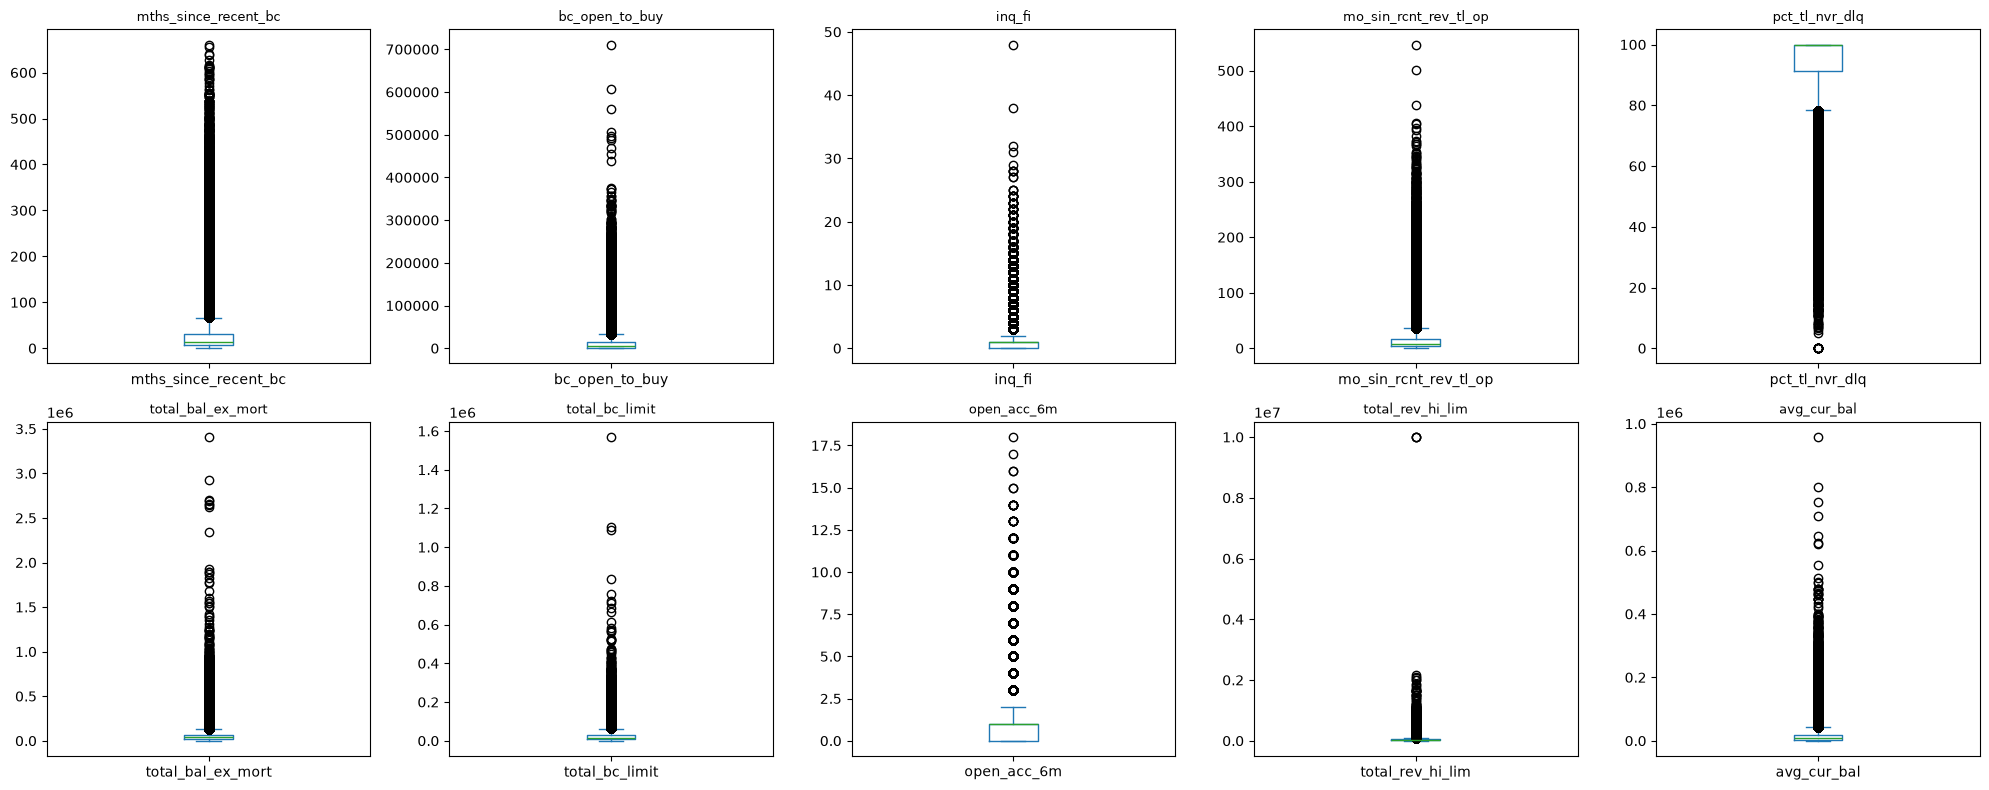

In [28]:
# Plot top columns with the most outliers
# Use continuous_cols not numeric_cols
top_cols = outlier_summary.head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, col in zip(axes.flatten(), top_cols):
    df[col].plot(kind='box', ax=ax)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()


Notes: TBD

## Define target variable and save the cleaned dataset to .csv file

In [29]:
# Update the 'loan_status' column to meet out binary target variable requirement
df['default'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1,
    'Default': 1,
    'Late (31-120 days)': 1,
    'Does not meet the credit policy. Status:Fully Paid': 0,
    'Does not meet the credit policy. Status:Charged Off': 1
})

# Remove the original 'loan_status' column as it's no longer needed
df = df.drop(columns=['loan_status'])

# Drop rows where default is NaN (excluded statuses)
df = df.dropna(subset=['default'])

# Convert default to integer type
df['default'] = df['default'].astype(int)

# Count of values in 'default' column
defaults_counts = df['default'].value_counts()
defaults_percentages = df['default'].value_counts(normalize=True) * 100

# Add to a DataFrame for better visualization
default_summary = pd.DataFrame({
    'Count': defaults_counts,
    'Percentage': defaults_percentages
})

print("Summary of 'default' column:")
default_summary


Summary of 'default' column:


,Count,Percentage
default,,
0,1078739,78.765025
1,290827,21.234975


Note: 
Note: The target variable `default` is defined as a binary outcome based on `loan_status`:

- **0 (Not Default):** `Fully Paid` and `Does not meet the credit policy. Status:Fully Paid`
- **1 (Default):** `Charged Off`, `Default`, `Late (31-120 days)`, and `Does not meet the credit policy. Status:Charged Off`

Final class distribution:
- 0 (Not Default): 1,078,739 rows (78.8%)
- 1 (Default): 290,827 rows (21.2%)

In [30]:
# Save the cleaned dataset to data/processed folder
df.to_csv(os.path.join(BASE_DIR, "data/processed/cleaned_accepted_loans.csv"), index=False)